In [30]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
# import seaborn as sns
import requests
import json
from pybliometrics import scopus
from wordcloud import WordCloud, ImageColorGenerator
import PIL.Image

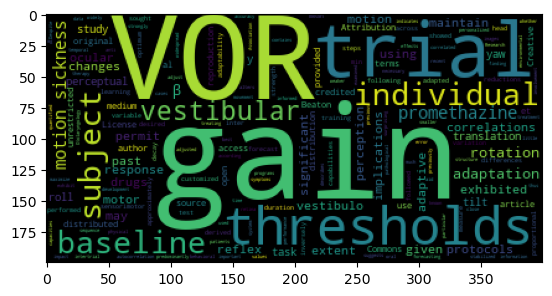

In [16]:
abstract_example = scopus.AbstractRetrieval('2-s2.0-85016953902', view='FULL').abstract+\
scopus.AbstractRetrieval('2-s2.0-85018846595', view='FULL').abstract

wc = WordCloud().generate(abstract_example )
plt.imshow(wc)

In [17]:
def clean_bibliography(uncleaned_bibliography, DOI=True, titles=True, EID=True, ISBN=True, PMID=True, **kwargs):
    '''
    Create bibliography of true positives based on dataframe of DOIs, titles, and/or EIDs
    uncleaned_bibliography (pd.DataFrame): 
    '''
    bibliography=pd.DataFrame()
    for row in uncleaned_bibliography.itertuples():
        if DOI:
            bibliography = pd.concat([bibliography, pd.DataFrame(scopus.ScopusSearch(f'DOI("{row.DOI}")',\
                                                                        subscriber=False, **kwargs).results)])
        if titles:
            bibliography = pd.concat([bibliography, pd.DataFrame(scopus.ScopusSearch(f'TITLE-ABS-KEY("{row.Title}")',\
                                                                        subscriber=False, **kwargs).results)])
        if EID:
            bibliography = pd.concat([bibliography, pd.DataFrame(scopus.ScopusSearch(f'EID({row.EID})', \
                                                                        subscriber=False, **kwargs).results)])
        if PMID:
            bibliography = pd.concat([bibliography, pd.DataFrame(scopus.ScopusSearch(f'PMID({row.PMID})', \
                                                                        subscriber=False, **kwargs).results)])
        if ISBN:
            bibliography = pd.concat([bibliography, pd.DataFrame(scopus.ScopusSearch(f'ISBN({row.ISBN})', \
                                                                        subscriber=False, **kwargs).results)])
        
        
    bibliography.set_index('eid', inplace=True)
    
    return bibliography

BA_true_positives = pd.read_excel('Master Bibliography for AB_BA_SBE (1).xlsx', sheet_name="BA True Positives", skiprows=1)
BA_true_positives['PMID'] = BA_true_positives['PMID'].fillna(0)
BA_true_positives['ISBN'] = BA_true_positives['ISBN'].fillna(0)
BA_true_positives = BA_true_positives.astype({'PMID':'int', 'ISBN':'int'})


# add EID to BA True Positives Table
BA_true_positives_bib = clean_bibliography(BA_true_positives, titles=False)


In [70]:
BA_mask_1 = np.array(PIL.Image.open('BA_helmet.jpeg'))
BA_mask_2 = np.array(PIL.Image.open('BA_helmet_2.jpeg'))
BA_mask_3 = np.array(PIL.Image.open('BA_helmet_3.png'))
BA_mask_4 = np.array(PIL.Image.open('BA_helmet_4.png'))
BA_mask_5 = np.array(PIL.Image.open('BA_astronaut_1.jpeg'))
BA_mask_6 = np.array(PIL.Image.open('BA_astronaut_2.jpeg'))

colormap_1 = ImageColorGenerator(BA_mask_1)
colormap_2 = ImageColorGenerator(BA_mask_2)
colormap_3 = ImageColorGenerator(BA_mask_3)
colormap_4 = ImageColorGenerator(BA_mask_4)
colormap_5 = ImageColorGenerator(BA_mask_5)
colormap_6 = ImageColorGenerator(BA_mask_6)



AxesImage(size=(902, 889))


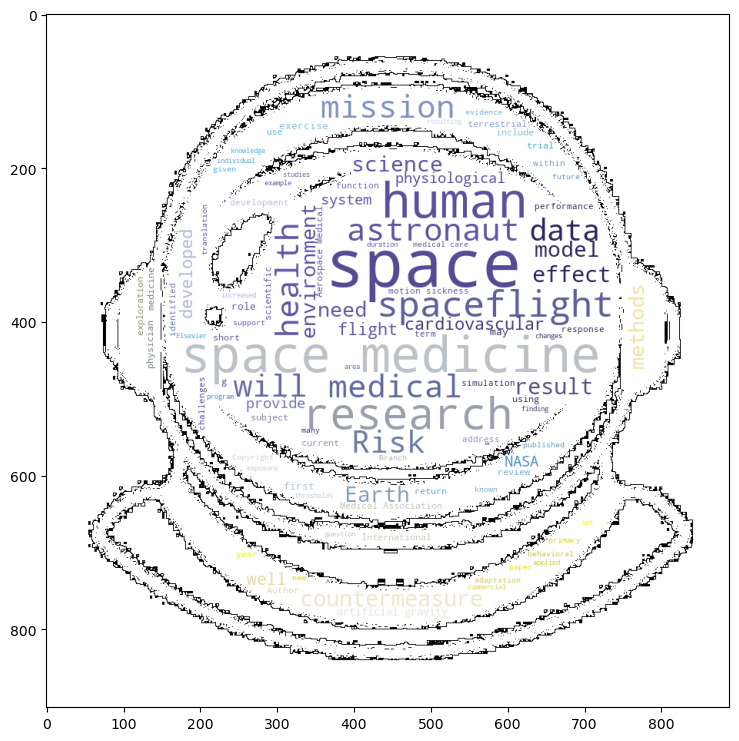

In [84]:


fig, ax = plt.subplots(figsize=(16, 9))
    
    
wc = WordCloud(mask=BA_mask_1,
              background_color='white',
              contour_color='black',
              contour_width=1,
              min_font_size=3,
              max_words=100).generate(abstract_string)
wc.recolor(color_func=colormap_1)
ax.imshow(wc)

In [85]:
def create_abstract_text_file(bibliographic_dataframe, file_name='compiled_abstracts.txt', autocloud=False, **kwds):
    '''
    Create text file combining all abstracts for a given bibliography.
    bibliographic_dataframe (pandas.DataFrame): expects index column to be of EIDs.
    file_name (str): name to be assigned to outputted text file
    autocloud (bool): if True, automatically returns a wordcloud representation of the text file.
    '''
    abstract_string = ' '
    for eid in bibliographic_dataframe.index:
        new_abstract = scopus.AbstractRetrieval(eid, view='FULL').abstract
        if new_abstract:
            abstract_string+=' '+new_abstract

    text_file = open(file_name, "w")
    text_file.write(abstract_string)
    text_file.close()
    
    if autocloud:
        wc = WordCloud(**kwds).generate(abstract_string)
        return ax.imshow(wc)